In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools


#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score


from multiprocessing import Pool, cpu_count

import dask
import dask.dataframe as dd
from dask.distributed import Client
#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


### Import Individual GRF

In [2]:
# Individual GRFs by cutoff intermediate
def read_csv(file_path):
    return pd.read_csv(file_path)
def merge_dfs(dfs):
    return pd.concat(dfs, ignore_index=True)

intermediate_results_folder_path = "../../data/output/intermediate_by_cutoff/"
csv_files = [os.path.join(intermediate_results_folder_path, f) for f in os.listdir(intermediate_results_folder_path) if f.endswith('.csv')]
pool = Pool()
dfs = pool.map(read_csv, csv_files)
merged_individual_grfs_df = merge_dfs(dfs)
merged_individual_grfs_df = merged_individual_grfs_df.sort_values(['fips','days_from_start'])
merged_individual_grfs_df = merged_individual_grfs_df.rename(columns={"tau.hat":"r_individual_grf", "datetime":"date"})
merged_individual_grfs_df["date"] = pd.to_datetime(merged_individual_grfs_df["date"])
merged_individual_grfs_df = merged_individual_grfs_df[["fips", "days_from_start", "r_individual_grf"]]
merged_individual_grfs_df.to_csv("../../data/output/glob_merged_individual_grfs.csv",index=False)

### Import Augmented DF

In [3]:
augmented_df = dd.read_csv("../../data/augmented_us-counties_latest.csv", assume_missing=True).compute()
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

# Check for gaps
gt_columns = ["fips", "state", "county", "date", "days_from_start", "log_rolled_cases", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")

/home/zwang937/anaconda3/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Generate Predictions for Individual GRFs

In [4]:
individual_grf_df = pd.merge(merged_individual_grfs_df, augmented_df_gt, on=["fips", "days_from_start"], how="right")
individual_grf_df["individual_grf_predicted_log_rolled_cases"] = individual_grf_df["r_individual_grf"]*7 + individual_grf_df["log_rolled_cases"]
individual_grf_df = individual_grf_df[individual_grf_df["date"] <= "2022-12-31"]

In [5]:
grouped = individual_grf_df.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")

### Import TLGRF Benchmark Dataset

In [6]:
benchmark_TLGRF_dataset = dd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv", assume_missing=True).compute()
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= np.log(21.1)]
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["date"] <= "2022-12-31"]
benchmark_TLGRF_dataset = benchmark_TLGRF_dataset.sort_values(by=["fips","date"])
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
17,1001.0,86.0,NaN,NaN,Autauga,Alabama,2020-04-16,20.285714,3.062723,3.133629,NaN
18,1001.0,87.0,-26.766326,0.028066,Autauga,Alabama,2020-04-17,20.714286,3.082565,3.170286,3.279026
19,1001.0,88.0,-313.778047,0.007752,Autauga,Alabama,2020-04-18,20.714286,3.082565,3.205646,3.136830
20,1001.0,89.0,-60.990643,0.021119,Autauga,Alabama,2020-04-19,21.000000,3.095578,3.228543,3.243410
21,1001.0,90.0,-54.020959,0.022045,Autauga,Alabama,2020-04-20,21.428571,3.114784,3.256447,3.269100
...,...,...,...,...,...,...,...,...,...,...,...
10119,99999.0,1071.0,2837.736966,-0.006383,New York City,New York,2022-12-27,81539.428571,11.308855,11.249207,11.264175
10120,99999.0,1072.0,2628.429057,-0.007237,New York City,New York,2022-12-28,80849.571429,11.300359,11.241229,11.249699
10121,99999.0,1073.0,2338.714337,-0.008885,New York City,New York,2022-12-29,80031.285714,11.290187,11.234906,11.227992
10122,99999.0,1074.0,2540.040095,-0.007669,New York City,New York,2022-12-30,79315.142857,11.281198,11.229165,11.227516


### Evaluate Performance of `TLGRF` and `individual_grf`

In [7]:
RMSE_individual_grf_df = individual_grf_df.groupby("date").apply(lambda x : np.sqrt(np.nanmean(np.square(x["individual_grf_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))) )
MAE_individual_grf_df = individual_grf_df.groupby("date").apply(lambda x : np.nanmean(np.abs(x["individual_grf_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))) 

RMSE_TLGRF_df = benchmark_TLGRF_dataset.groupby("date").apply(lambda x : np.sqrt(np.nanmean(np.square(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))) )
MAE_TLGRF_df = benchmark_TLGRF_dataset.groupby("date").apply(lambda x : np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))) 


/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: Mean of empty slice
  """Entry point for launching an IPython kernel.
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: RuntimeWarning: Mean of empty slice
  
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: RuntimeWarning: Mean of empty slice
  after removing the cwd from sys.path.
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:5: RuntimeWarning: Mean of empty slice
  """


In [8]:
metrics_df = pd.DataFrame()
metrics_df["MAE"] = [MAE_individual_grf_df.median(), MAE_TLGRF_df.median()]
metrics_df["RMSE"] = [RMSE_individual_grf_df.median(), RMSE_TLGRF_df.median()]
metrics_df.index = ["Individual GRFs Time Only", "TLGRF"]
#metrics_df = metrics_df.rename_axis("Method")
display(metrics_df)

,MAE,RMSE
Individual GRFs Time Only,0.215557,0.290983
TLGRF,0.126516,0.194870


In [9]:
latex_table = metrics_df.to_latex(column_format='c'*len(metrics_df.columns), float_format='%.3f', escape=False)
print(latex_table)

\begin{tabular}{cc}
\toprule
{} &   MAE &  RMSE \\
\midrule
Individual GRFs Time Only & 0.216 & 0.291 \\
TLGRF                     & 0.127 & 0.195 \\
\bottomrule
\end{tabular}



### Plot MAE and RMSE of Individual GRF vs TLGRF

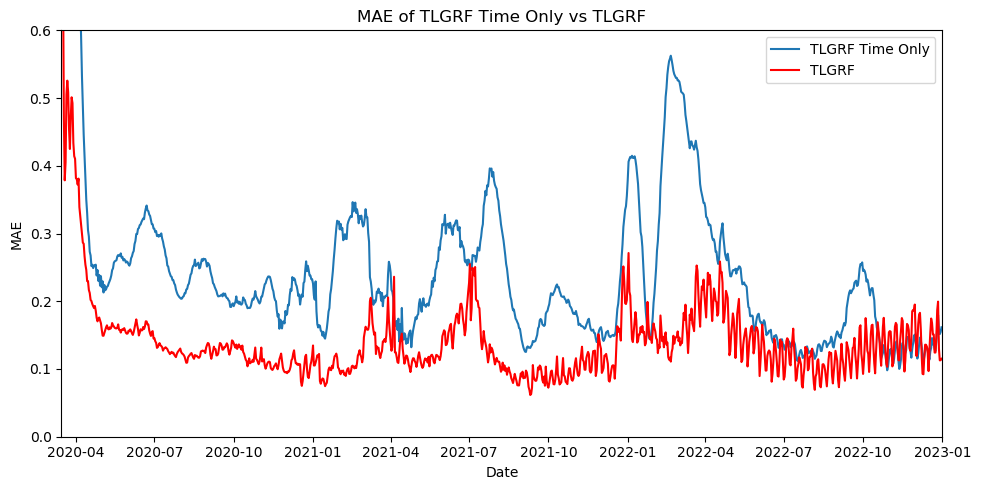

In [10]:
plt.figure(figsize=(10,5))

plt.plot(MAE_individual_grf_df, label="TLGRF Time Only")
plt.plot(MAE_TLGRF_df, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("MAE of TLGRF Time Only vs TLGRF")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.tight_layout()
plt.ylim(0,0.6)
plt.savefig("MAE TLGRF Time Only vs TLGRF.png")

plt.show()

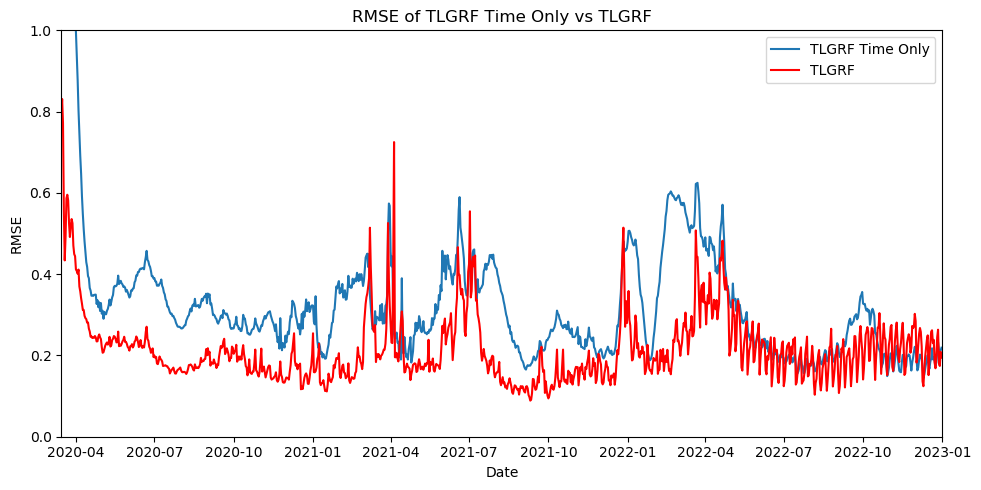

In [11]:
plt.figure(figsize=(10,5))

plt.plot(RMSE_individual_grf_df, label="TLGRF Time Only")
plt.plot(RMSE_TLGRF_df, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("RMSE of TLGRF Time Only vs TLGRF")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.tight_layout()
plt.ylim(0, 1.0)
plt.savefig("RMSE TLGRF Time Only vs TLGRF.png")

plt.show()